In [1]:
import random
import numpy as np
import pandas as pd
import h5py
import vaex
import pynbody
from pynbody.array import SimArray

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.path import Path

from astropy import units as u
from astropy.io import ascii, fits
from astropy.table import Table, vstack
from astropy.coordinates import SkyCoord,CartesianRepresentation,match_coordinates_sky

import functions as fn 
import matched_filter_ani as mf
import os

In [2]:
### Global Variables ###

### THESE ARE THE ONLY THINGS THAT NEED TO BE UPDATED BETWEEN RUNS
box = 'storm' 
num = 1


c1='px'
c2='py'
age = '10'
mh = '-2'
numpix= 4096
iso_info = 'parsec'
edgelength = 10 
gal = f"{box}_{num}"
year = 10
size_kpc=40


In [3]:
# Generates a random floating-point number between 0.0 and 2pi
azi_random = random.uniform(0, 2*np.pi)
dec_random = random.uniform(0, 2*np.pi)

def fibonacci_angler(n):

    golden_ratio = (1 + np.sqrt(5))/2

    i_array = np.linspace(0,n-1,n)
    z_array = 1 - i_array/((n-1)) 
    radius_array = np.sqrt(1-z_array**2)

    declination_array = np.pi/2-np.arcsin(z_array)
    azimuthal_array = 2*np.pi * i_array/golden_ratio
    

    return declination_array, azimuthal_array

dec_fixed, azi_fixed = fibonacci_angler(3)
dec = [x + dec_random for x in dec_fixed]
azi = [azi_fixed[x] + azi_random for x in range(len(azi_fixed))]

dec_deg = [round(np.mod(x*180/np.pi, 360),1) for x in dec]
azi_deg = [round(np.mod(x*180/np.pi, 360),1) for x in azi]

print(dec_deg, azi_deg)

[93.1, 153.1, 183.1] [102.0, 324.5, 187.0]


In [4]:
### THESE SHOULD BE CHANGED FOR EACH USER

more_base_path = "/home/otteleno/fall" # Path to Galaxy Folder
base_path = f"{more_base_path}/fall_data"  # Path to Data Folder


level2_params = [
    ("26p5", "2000"),
    ("26p5", "4000"),
    ("25", "2000"),
    ("25", "4000"),
]

root_folder = os.path.join(base_path, gal)

for param1, param2 in level2_params:
    level2_folder = f"{gal}_{param1}_{param2}"
    level2_path = os.path.join(root_folder, level2_folder)
    
    os.makedirs(level2_path, exist_ok=True)
    
    level3_folders = [
        f"{gal}_{param1}_{param2}_rot",
        f"{gal}_{param1}_{param2}_bg",
        f"{gal}_{param1}_{param2}_mf",
    ]
    
    for level3_folder in level3_folders:
        level3_path = os.path.join(level2_path, level3_folder)
        os.makedirs(level3_path, exist_ok=True)


In [5]:
def run_rot(pos_array, dec, azi):
    
    # spherical coordinates. Turns into radians.
    theta = dec
    phi = azi
    dec_readable = round(np.mod(dec*180/np.pi, 360),1)
    azi_readable = round(np.mod(azi*180/np.pi, 360),1)

    # use rotation matrix to find 2d projected image from any given angle of observation
    project_matrix = np.array([[-np.sin(phi),                np.cos(phi),             0            ],
                             [-np.cos(theta)*np.cos(phi), -np.cos(theta)*np.sin(phi), np.sin(theta)]])

    project_pos_array_all = np.matmul(project_matrix, pos_array) #applies 2x3 transformation to 3xn data. Result is 2xn data 

    
    dwarfcat['px'] = project_pos_array_all.T[:,0]
    dwarfcat['py'] = project_pos_array_all.T[:,1]
    
    rot_path = f"/{base_path}/{gal}/{gal}_{depth}_{dist}/{gal}_{depth}_{dist}_rot/{gal}_{depth}_{dist}_rot_{dec_readable}_{azi_readable}"
    vframe_new = vaex.from_pandas(dwarfcat)
    vframe_new.export_hdf5(rot_path)

    return

In [6]:
def run_bg(dec, azi):

    rot_path = f"/{base_path}/{gal}/{gal}_{depth}_{dist}/{gal}_{depth}_{dist}_rot/{gal}_{depth}_{dist}_rot_{dec}_{azi}"  
    bg_path = f"/{base_path}/{gal}/{gal}_{depth}_{dist}/{gal}_{depth}_{dist}_bg/{gal}_{depth}_{dist}_bg_{dec}_{azi}"  

    dwarf_table = fn.bg_dwarf_combo(pdist,name,year,D,c1,c2,plotdir,rot_path,bgcatpath,edgelength,plot=False,save=True,my_save_path = bg_path) 
    table_final = vstack([dwarf_table,bgtable])
    table_final.write(bg_path, format='fits',overwrite=True)
    
    return 
    

In [7]:
def run_mf(dec, azi):

    
    bg_path = f"/{base_path}/{gal}/{gal}_{depth}_{dist}/{gal}_{depth}_{dist}_bg/{gal}_{depth}_{dist}_bg_{dec}_{azi}"  
    mf_path = f"/{base_path}/{gal}/{gal}_{depth}_{dist}/{gal}_{depth}_{dist}_mf/{gal}_{depth}_{dist}_mf_{dec}_{azi}.fits"  
   
    mf.matched_filter_ani(objcmd, backcmd, mf_path,
        field=field, 
        catalog=bg_path,
        plot=True, rmaglim = rmaglim, pix=pix, pdist=pdist*60)

    return    
    

rot_0
rot_1
rot_2
bg_0
bg_1
bg_2
Total number of signal CMD
1.0


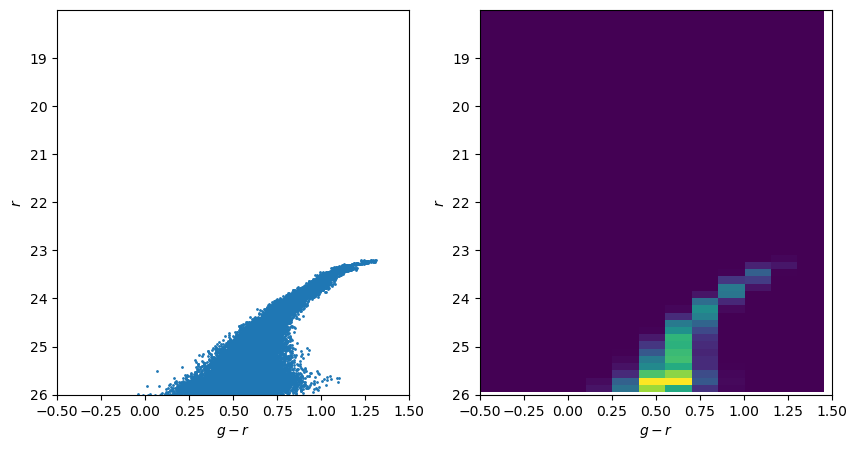

Total number of stars in background CMD
803.9991177949594


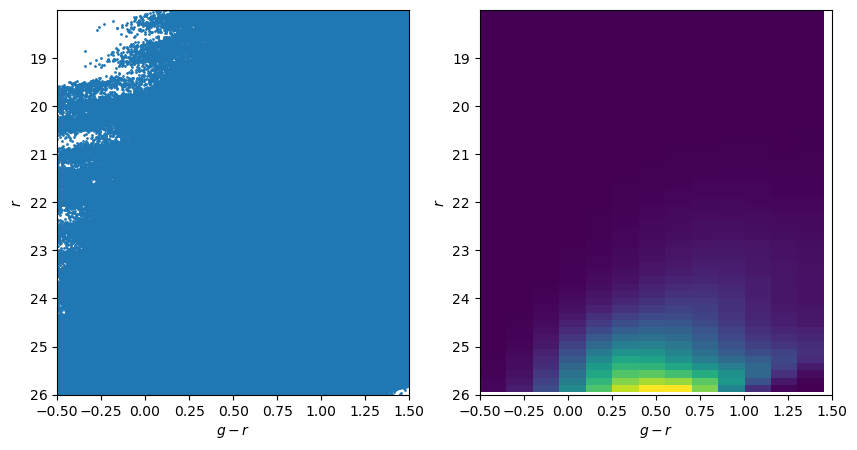

x min  -68.75493541569878
x max  68.75493541569878
y min  -68.75493541569878
y max  68.75493541569878


In [ ]:
for depth, dist in level2_params:
    
    ### Local Contingent Variables ###
    D = int(dist)

   
    if depth == '26p5':
        mlim = '26' 
    else:
        mlim = '25'

    pdist = (size_kpc/D) * (180/np.pi) 
    rmaglim = int(mlim)
    pix = (np.round(np.sqrt((2*pdist*60)**2 / numpix),2))
    
    name = f'{box}_4096_{num}_data_{D}_{depth}'
    plotdir = f'{box}_4096_{num}' 
    bgcatpath = f"/{more_base_path}/fall_files/bgcats/bgr{mlim}g{mlim}_for_mf_{int(edgelength)}deg.fits"
    field = name+f'_mfmag{rmaglim}_{iso_info}{age}{mh}{c1}{c2}_{np.round(pdist*60,0)}'
    signal_file = f"{more_base_path}/fall_files/signals/{iso_info}_{D}_{age}{mh}_{depth}_signal_cmd_gr.txt" 
    dwarfcatpath = f'{more_base_path}/fall_files/dwarfcats/{box}/{box}_catalogs_plots/{box}_4096_{num}_data_{dist}_{depth}/survey.{box}_4096_{num}_data_{dist}_{depth}.0.h5'


    ### Rotation ###

    #Sets up table
    vdwarfcat = vaex.open(dwarfcatpath)
    dwarfcat = pd.DataFrame(vdwarfcat,columns=vdwarfcat.column_names)
    ananke_data = np.column_stack([dwarfcat['px'],dwarfcat['py'], dwarfcat['pz']])
    ananke_masses = dwarfcat['smass']
    ananke_total_mass = np.sum(ananke_masses)
    
    cm_current_ananke = [0,0,0]
    for i in range(len(ananke_data)):
        cm_current_ananke = cm_current_ananke + ananke_data[i] * ananke_masses[i]
    cm_ananke = [x/ananke_total_mass for x in cm_current_ananke]
    
    ananke_data_centered = ananke_data - cm_ananke


    #Rotates

    for i in range(len(dec_deg)):
    
        run_rot(ananke_data_centered.T, dec[i], azi[i]) 
        print(f"rot_{i}")

    ### Background ###
    #Loads data
    bgcat = Table.read(bgcatpath,format='fits')
    c1bg = bgcat['c1']
    c2bg = bgcat['c2']
    bgtable = Table()
    bgtable['c1'] = c1bg
    bgtable['c2'] = c2bg
    bgtable['gmag'] = bgcat['gmag']
    bgtable['Ag'] = bgcat['Ag'] 
    bgtable['rmag'] = bgcat['rmag']
    bgtable['Ar'] = bgcat['Ar']
    bgtable['flag'] = 'bg'
    bgtable['age'] = -99    

    #Add backgrounds
    for i in range(len(dec_deg)):
    
        run_bg(dec_deg[i], azi_deg[i]) 
        print(f"bg_{i}")

    ### Matched Filter ###

    #Make CMDs
    objcmd = mf.mk_norm_objcmd_gd(field, signal_file, rmaglim=rmaglim, plot=True)   
    backcmd = mf.mk_norm_backcmd(field, bgcatpath, rmaglim=rmaglim, plot=True, pix=pix)

    #Run MF
    for i in range(len(dec_deg)):
    
        run_mf(dec_deg[i], azi_deg[i]) 
        print(f"mf_{i}")
